# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith('hte-and-targeting"'):
    os.chdir('..')

import logging
logger = logging.getLogger("pymc")
logger.propagate = False
logger.setLevel(logging.ERROR)

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [4]:
from sklearn.linear_model import LogisticRegression, Lasso

In [5]:
from core.variables import * 
import core.rct as rct
import core.targeting as tgt

# A/B Testing

## Fixed vs. Random Param DGP

### Fixed param DGP

In [5]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500, 'fixed_params': True}

estimators_dict = {
    'bayes_normal': {
        'estimator': rct.bayes_estimate,
        'params': {'prior': 'normal', 'prior_mean': 0, 'prior_std': 1},
        'display_name': 'Shrinkage with Bayes'
    }, 
}

In [6]:
result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict,
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = rct.calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    2.8s finished


In [7]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    wc_avg = wc_measures_dict['rank_and_select_nc_wc_avg']
    wc_se = wc_measures_dict['rank_and_select_nc_wc_se'] 

    val_true_avg = wc_measures_dict['rank_and_select_nc_val_true_avg']
    val_est_avg = wc_measures_dict['rank_and_select_nc_val_est_avg']
    val_true_se = wc_measures_dict['rank_and_select_nc_val_true_se']
    val_est_se = wc_measures_dict['rank_and_select_nc_val_est_se']

    # bayesian results
    bayes_wc_avg = wc_measures_dict['rank_and_select_bayes_normal_wc_avg']
    bayes_wc_se = wc_measures_dict['rank_and_select_bayes_normal_wc_se']
    bayes_val_est_avg = wc_measures_dict['rank_and_select_bayes_normal_val_est_avg']
    bayes_val_est_se = wc_measures_dict['rank_and_select_bayes_normal_val_est_se']

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Average Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Average Bayes Estimated Value: {bayes_val_est_avg:.4f} ({bayes_val_est_se:.4f})')
    print()
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')
    print(f'  - Average Bayes Winner\'s Curse (%): {bayes_wc_avg/delta_tau:.2%} ({bayes_wc_se/delta_tau:.2%})')


Selection with Rank and Select:
  - Average True Value: 1.0764 (0.0042)
  - Average Estimated Value: 1.1196 (0.0088)
  - Average Bayes Estimated Value: 1.1086 (0.0087)

  - Average Winner's Curse (%): 43.15% (9.10%)
  - Average Bayes Winner's Curse (%): 32.22% (9.02%)


### Random param DGP

In [63]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [UnivariateGaussian(1, 0.1), UnivariateGaussian(1.1, 0.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 1000, 'fixed_params': False}

estimators_dict = {
    'bayes_normal': {
        'estimator': rct.bayes_estimate,
        'params': {'prior': 'normal', 'prior_mean': 1, 'prior_std': 1},
        'display_name': 'Shrinkage with Bayes'
    }, 
}

In [64]:
result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict,
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = rct.calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


In [65]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    wc_avg = wc_measures_dict['rank_and_select_nc_wc_avg']
    wc_se = wc_measures_dict['rank_and_select_nc_wc_se'] 

    val_true_avg = wc_measures_dict['rank_and_select_nc_val_true_avg']
    val_est_avg = wc_measures_dict['rank_and_select_nc_val_est_avg']
    val_true_se = wc_measures_dict['rank_and_select_nc_val_true_se']
    val_est_se = wc_measures_dict['rank_and_select_nc_val_est_se']

    # bayesian results
    bayes_wc_avg = wc_measures_dict['rank_and_select_bayes_normal_wc_avg']
    bayes_wc_se = wc_measures_dict['rank_and_select_bayes_normal_wc_se']
    bayes_val_est_avg = wc_measures_dict['rank_and_select_bayes_normal_val_est_avg']
    bayes_val_est_se = wc_measures_dict['rank_and_select_bayes_normal_val_est_se']

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Average Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Average Bayes Estimated Value: {bayes_val_est_avg:.4f} ({bayes_val_est_se:.4f})')
    print()
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')
    print(f'  - Average Bayes Winner\'s Curse (%): {bayes_wc_avg/delta_tau:.2%} ({bayes_wc_se/delta_tau:.2%})')


Selection with Rank and Select:
  - Average True Value: 1.1048 (0.0094)
  - Average Estimated Value: 1.1436 (0.0121)
  - Average Bayes Estimated Value: 1.1422 (0.0120)

  - Average Winner's Curse (%): 38.81% (9.25%)
  - Average Bayes Winner's Curse (%): 37.40% (9.18%)


## Negative Effects

In [6]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(-1.1), PointMass(-1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500, 'fixed_params': True}

estimators_dict = {
    'bayes_normal': {
        'estimator': rct.bayes_estimate,
        'params': {'prior': 'normal', 'prior_mean': 0, 'prior_std': 1},
        'display_name': 'Shrinkage with Bayes'
    }, 
}

In [7]:
result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict,
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = rct.calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    2.8s finished


In [ ]:
delta_tau = np.abs(dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean)

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    wc_avg = wc_measures_dict['rank_and_select_nc_wc_avg']
    wc_se = wc_measures_dict['rank_and_select_nc_wc_se'] 

    val_true_avg = wc_measures_dict['rank_and_select_nc_val_true_avg']
    val_est_avg = wc_measures_dict['rank_and_select_nc_val_est_avg']
    val_true_se = wc_measures_dict['rank_and_select_nc_val_true_se']
    val_est_se = wc_measures_dict['rank_and_select_nc_val_est_se']

    # bayesian results
    bayes_wc_avg = wc_measures_dict['rank_and_select_bayes_normal_wc_avg']
    bayes_wc_se = wc_measures_dict['rank_and_select_bayes_normal_wc_se']
    bayes_val_est_avg = wc_measures_dict['rank_and_select_bayes_normal_val_est_avg']
    bayes_val_est_se = wc_measures_dict['rank_and_select_bayes_normal_val_est_se']

    print(f'\nPolicy Value:')
    print(f'  - True: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - No Correction: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Bayesian: {bayes_val_est_avg:.4f} ({bayes_val_est_se:.4f})')
    print(f'\nWinner\'s Curse (%):')
    print(f'  - No Correction: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')
    print(f'  - Bayesian: {bayes_wc_avg/delta_tau:.2%} ({bayes_wc_se/delta_tau:.2%})')



Selection with Rank and Select:
  - Average True Value: -1.0236 (0.0042)
  - Average Estimated Value: -0.9804 (0.0088)
  - Average Bayes Estimated Value: -0.9709 (0.0087)

  - Average Winner's Curse (%): 43.15% (9.10%)
  - Average Bayes Winner's Curse (%): 52.73% (9.02%)


# Targeting

## Negative Effects

In [25]:
optimization_params = {
    'rank_and_select': {
        'optimizer': tgt.optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(-1.1), PointMass(-1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': tgt.CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': tgt.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': tgt.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': tgt.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'bayes_normal': {
        'estimator': tgt.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayesian'
    }, 
    'eb_spike_slab': {
        'estimator': tgt.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'Empirical Bayes'
    }, 
}

In [7]:
tgt_result_records = tgt.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

tgt_wc_measures_dict = tgt.calculate_winners_curse_measures(
    result_records=tgt_result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.8min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 22.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.4min finished


Policy Value: 
  - True Value: -1.0328 (0.0178)
  - No Correction: -0.8596 (0.0224)
  - Standard Bootstrap: -0.9887 (0.0252)
  - m-out-of-n Bootstrap: -1.0242 (0.0258)
  - Numerical Bootstrap: -1.0301 (0.0263)
  - Bayesian: -0.6507 (0.0185)
  - Empirical Bayes: -0.7961 (0.0207)

Winner's Curse: 
Average: 
  - No Correction: 173.27% (18.36%)
  - Standard Bootstrap: 44.15% (21.26%)
  - m-out-of-n Bootstrap: 8.66% (21.28%)
  - Numerical Bootstrap: 2.70% (22.53%)
  - Bayesian: 382.12% (17.39%)
  - Empirical Bayes: 236.75% (16.95%)
Median: 
  - No Correction: 173.18% (18.36%)
  - Standard Bootstrap: 51.85% (21.26%)
  - m-out-of-n Bootstrap: 9.74% (21.28%)
  - Numerical Bootstrap: 6.26% (22.53%)
  - Bayesian: 378.09% (17.39%)
  - Empirical Bayes: 234.64% (16.95%)


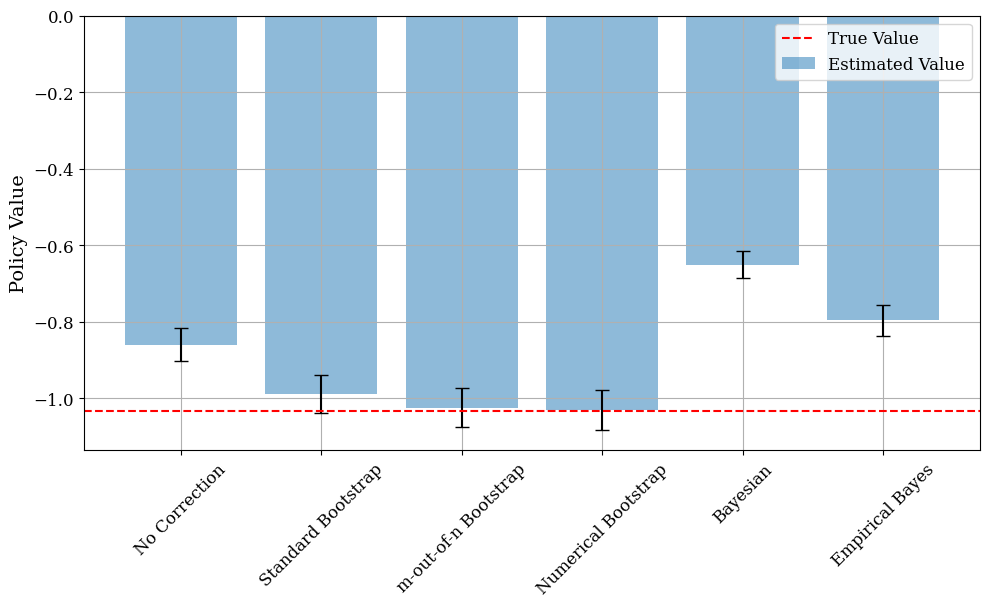

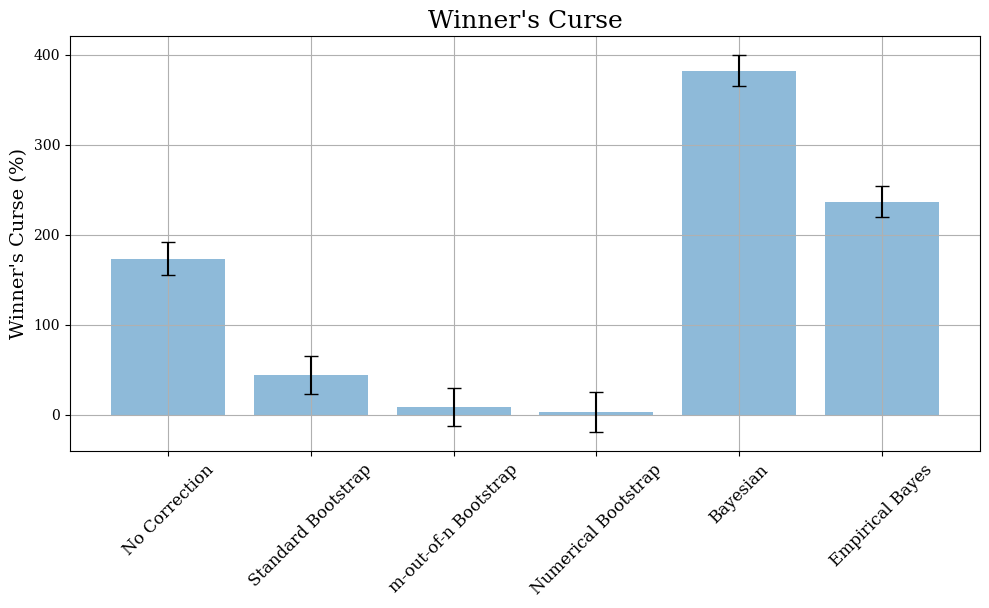

In [34]:
delta_tau = np.abs(dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean)

optimizer_key = 'rank_and_select'

# print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

val_true_avg = tgt_wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = tgt_wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

print(f'Policy Value: ')
print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    est_avg = tgt_wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    est_se = tgt_wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {est_avg:.4f} ({est_se:.4f})')

print(f'\nWinner\'s Curse: ')
print(f"Average: ")
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_avg = tgt_wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_avg']
    wc_se = tgt_wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

print(f'Median: ')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_median = np.nanmedian(tgt_wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_arr'])
    wc_se = tgt_wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_median/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

if 'sample_splitting' in estimators_dict.keys():
    print(f'\nSample Splitting: ')
    ss_val_true_avg = tgt_wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = tgt_wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    ss_val_est_avg = tgt_wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
    ss_val_est_se = tgt_wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
    ss_wc_avg = tgt_wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
    ss_wc_se = tgt_wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

    print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
    print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {ss_wc_avg/delta_tau:.2%} ({ss_wc_se/delta_tau:.2%})')

""" 
Visualize the Policy Value
"""

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(estimators_dict.keys()) + 1 - int('sample_splitting' in estimators_dict.keys()))
bar_values = [
    tgt_wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]
bar_errors = [
    1.96 * tgt_wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
if 'sample_splitting' in estimators_dict.keys():
    # two side-by-side bars for sample splitting, one for true value and one for estimated value
    bar_width = 0.4
    ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
    ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
# ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection', fontsize=title_size)
if 'sample_splitting' in estimators_dict.keys():
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items() if k != 'sample_splitting'] + ['Sample Splitting'], 
        rotation=45, 
        fontsize=tick_label_size
    )
else:
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items()], 
        rotation=45, 
        fontsize=tick_label_size
    )
# ax.set_ylim([0.9, 1.2])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(loc='upper right', fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

viz_estimators = ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
wc_avg_list = [tgt_wc_measures_dict[f'rank_and_select_{estimator}_wc_avg'] / delta_tau * 100 for estimator in viz_estimators]
wc_se_list = [tgt_wc_measures_dict[f'rank_and_select_{estimator}_wc_se'] / delta_tau * 100 for estimator in viz_estimators]

ax.bar(
    np.arange(len(viz_estimators)),
    wc_avg_list,
    yerr=wc_se_list, 
    capsize=5, 
    color='C0', 
    alpha=0.5, 
)

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_title('Winner\'s Curse', fontsize=title_size)
ax.set_xticks(
    np.arange(len(viz_estimators)),
    [estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction' for estimator in viz_estimators], 
    fontsize=tick_label_size, 
    rotation=45
)
ax.grid()
plt.tight_layout()
plt.show()